In [1]:
pip install librosa scipy matplotlib numpy

     ---------------------------------------- 0.0/260.7 kB ? eta -:--:--
     --------- ----------------------------- 61.4/260.7 kB 1.1 MB/s eta 0:00:01
     -------------- ----------------------- 102.4/260.7 kB 1.2 MB/s eta 0:00:01
     -------------------------------- ----- 225.3/260.7 kB 1.7 MB/s eta 0:00:01
     -------------------------------------  256.0/260.7 kB 1.6 MB/s eta 0:00:01
     -------------------------------------- 260.7/260.7 kB 1.1 MB/s eta 0:00:00
     ---------------------------------------- 0.0/70.1 kB ? eta -:--:--
     ----------------- ---------------------- 30.7/70.1 kB ? eta -:--:--
     --------------------------------- ---- 61.4/70.1 kB 825.8 kB/s eta 0:00:01
     --------------------------------- ---- 61.4/70.1 kB 825.8 kB/s eta 0:00:01
     -------------------------------------- 70.1/70.1 kB 479.0 kB/s eta 0:00:00
     ---------------------------------------- 0.0/67.2 kB ? eta -:--:--
     ------------------------------------ --- 61.4/67.2 kB 1.6 MB/s et


[notice] A new release of pip is available: 23.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import librosa

original, sr = librosa.load(
    "original.mp3",
    sr=22050,
    mono=True
)

karaoke, _ = librosa.load(
    "karaoke.mp3",
    sr=22050,
    mono=True
)

different, _ = librosa.load(
    "different.mp3",
    sr=22050,
    mono=True
)

c:\Users\heerm\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
duration = 30

samples = sr * duration

original = original[:samples]
karaoke = karaoke[:samples]
different = different[:samples]

In [2]:
import librosa
import numpy as np
from scipy.signal import correlate

durations = [10, 20, 30, 45, 60]

print("-" * 90)
print(f"{'Duration':<10}{'Pearson OK':<15}{'Pearson OD':<15}{'Pearson KD':<15}"
      f"{'Cross OK':<15}{'Cross OD':<15}{'Cross KD':<15}")
print("-" * 90)

for duration in durations:

    # Reload the audio each time
    original, sr = librosa.load("original.mp3",
                                sr=22050,
                                mono=True)

    karaoke, _ = librosa.load("karaoke.mp3",
                              sr=22050,
                              mono=True)

    different, _ = librosa.load("different.mp3",
                                sr=22050,
                                mono=True)

    samples = duration * sr

    original = original[:samples]
    karaoke = karaoke[:samples]
    different = different[:samples]

    min_len = min(len(original), len(karaoke), len(different))

    original = original[:min_len]
    karaoke = karaoke[:min_len]
    different = different[:min_len]

    # Normalize
    original = original / np.max(np.abs(original))
    karaoke = karaoke / np.max(np.abs(karaoke))
    different = different / np.max(np.abs(different))

    # Pearson
    p_ok = np.corrcoef(original, karaoke)[0,1]
    p_od = np.corrcoef(original, different)[0,1]
    p_kd = np.corrcoef(karaoke, different)[0,1]

    # Cross Correlation
    c_ok = correlate(original, karaoke, mode='full')
    c_od = correlate(original, different, mode='full')
    c_kd = correlate(karaoke, different, mode='full')

    c_ok = c_ok / np.sqrt(np.sum(original**2) * np.sum(karaoke**2))
    c_od = c_od / np.sqrt(np.sum(original**2) * np.sum(different**2))
    c_kd = c_kd / np.sqrt(np.sum(karaoke**2) * np.sum(different**2))

    print(f"{duration:<10}"
          f"{p_ok:<15.6f}"
          f"{p_od:<15.6f}"
          f"{p_kd:<15.6f}"
          f"{np.max(c_ok):<15.6f}"
          f"{np.max(c_od):<15.6f}"
          f"{np.max(c_kd):<15.6f}")

------------------------------------------------------------------------------------------
Duration  Pearson OK     Pearson OD     Pearson KD     Cross OK       Cross OD       Cross KD       
------------------------------------------------------------------------------------------
10        -0.054041      -0.001313      0.011337       0.147417       0.020863       0.038832       
20        -0.000199      0.001989       0.001441       0.063784       0.021477       0.023646       
30        0.018168       -0.001258      0.000761       0.049849       0.016466       0.027517       
45        0.011891       -0.001036      -0.001295      0.079920       0.016318       0.020935       
60        0.000758       -0.002600      -0.001981      0.062730       0.014820       0.016309       


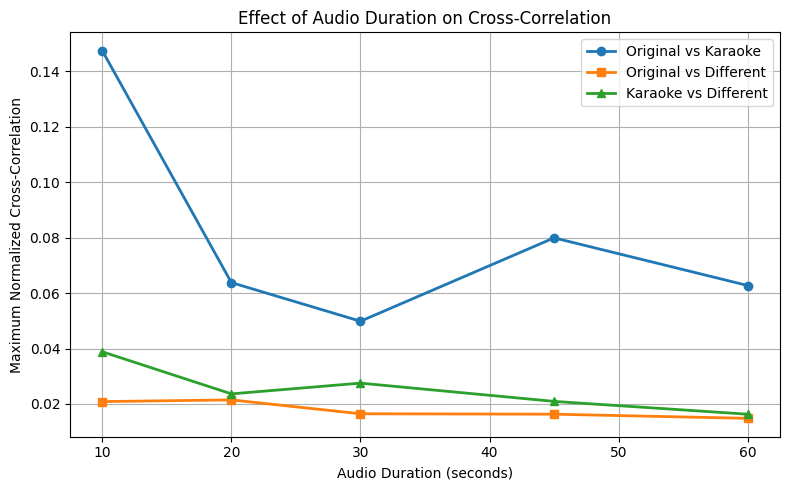

In [3]:
import matplotlib.pyplot as plt

durations = [10, 20, 30, 45, 60]

cross_ok = [0.147417, 0.063784, 0.049849, 0.079920, 0.062730]
cross_od = [0.020863, 0.021477, 0.016466, 0.016318, 0.014820]
cross_kd = [0.038832, 0.023646, 0.027517, 0.020935, 0.016309]

plt.figure(figsize=(8,5))

plt.plot(durations, cross_ok, marker='o', linewidth=2,
         label='Original vs Karaoke')

plt.plot(durations, cross_od, marker='s', linewidth=2,
         label='Original vs Different')

plt.plot(durations, cross_kd, marker='^', linewidth=2,
         label='Karaoke vs Different')

plt.xlabel("Audio Duration (seconds)")
plt.ylabel("Maximum Normalized Cross-Correlation")
plt.title("Effect of Audio Duration on Cross-Correlation")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("experiment1_cross_duration.png", dpi=300)

plt.show()

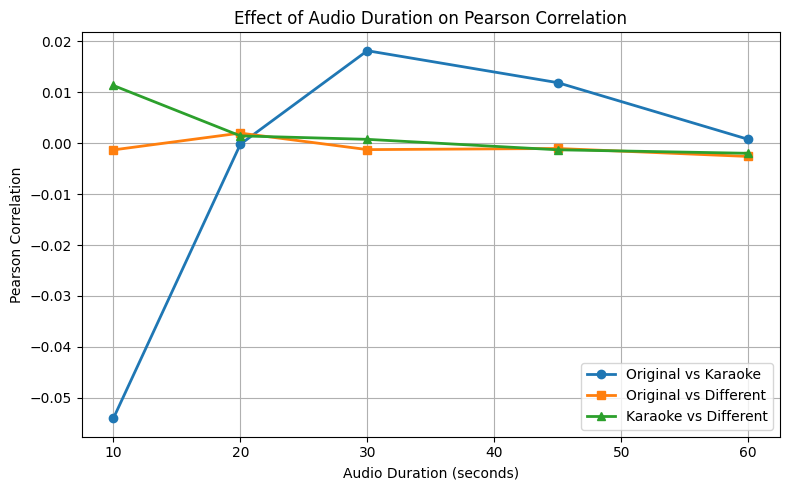

In [4]:
pearson_ok = [-0.054041,-0.000199,0.018168,0.011891,0.000758]
pearson_od = [-0.001313,0.001989,-0.001258,-0.001036,-0.002600]
pearson_kd = [0.011337,0.001441,0.000761,-0.001295,-0.001981]

plt.figure(figsize=(8,5))

plt.plot(durations, pearson_ok,
         marker='o',
         linewidth=2,
         label='Original vs Karaoke')

plt.plot(durations, pearson_od,
         marker='s',
         linewidth=2,
         label='Original vs Different')

plt.plot(durations, pearson_kd,
         marker='^',
         linewidth=2,
         label='Karaoke vs Different')

plt.xlabel("Audio Duration (seconds)")
plt.ylabel("Pearson Correlation")
plt.title("Effect of Audio Duration on Pearson Correlation")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("experiment1_pearson_duration.png", dpi=300)

plt.show()

In [5]:
min_len = min(len(original), len(karaoke), len(different))

original = original[:min_len]
karaoke = karaoke[:min_len]
different = different[:min_len]

In [6]:
import numpy as np

original = original / np.max(np.abs(original))
karaoke = karaoke / np.max(np.abs(karaoke))
different = different / np.max(np.abs(different))

In [7]:
corr_ok = np.corrcoef(original, karaoke)[0, 1]
corr_od = np.corrcoef(original, different)[0, 1]
corr_kd = np.corrcoef(karaoke, different)[0, 1]

print("Original vs Karaoke :", corr_ok)
print("Original vs Different:", corr_od)
print("Karaoke vs Different :", corr_kd)

Original vs Karaoke : 0.01816849955644602
Original vs Different: -0.0012579030610307864
Karaoke vs Different : 0.0007607061375107056


In [8]:
from scipy.signal import correlate

cross_ok = correlate(original, karaoke, mode="full")
cross_od = correlate(original, different, mode="full")
cross_kd = correlate(karaoke, different, mode="full")

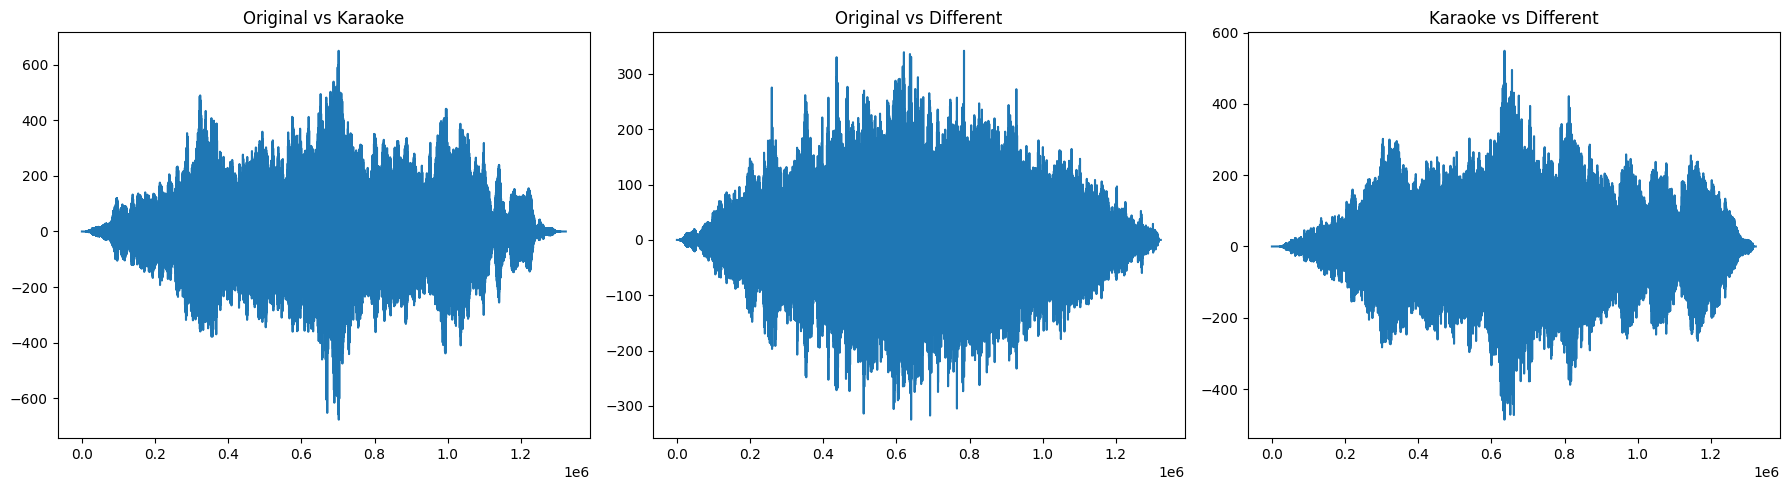

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(cross_ok)
plt.title("Original vs Karaoke")

plt.subplot(1,3,2)
plt.plot(cross_od)
plt.title("Original vs Different")

plt.subplot(1,3,3)
plt.plot(cross_kd)
plt.title("Karaoke vs Different")

plt.tight_layout()
plt.show()

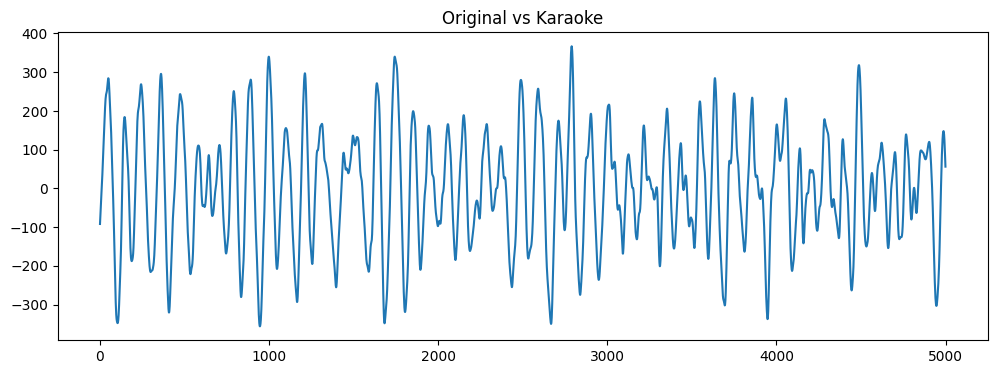

In [10]:
mid = len(cross_ok)//2

plt.figure(figsize=(12,4))
plt.plot(cross_ok[mid-2500:mid+2500])
plt.title("Original vs Karaoke")
plt.show()

In [11]:
print(np.max(cross_ok))
print(np.max(cross_od))
print(np.max(cross_kd))

649.3511
341.87222
548.75385


In [12]:
from scipy.signal import correlate
import numpy as np

cross_ok = correlate(original, karaoke, mode='full')
cross_od = correlate(original, different, mode='full')
cross_kd = correlate(karaoke, different, mode='full')

# Normalize by signal energies
cross_ok = cross_ok / np.sqrt(np.sum(original**2) * np.sum(karaoke**2))
cross_od = cross_od / np.sqrt(np.sum(original**2) * np.sum(different**2))
cross_kd = cross_kd / np.sqrt(np.sum(karaoke**2) * np.sum(different**2))

print("Max Original vs Karaoke :", np.max(cross_ok))
print("Max Original vs Different :", np.max(cross_od))
print("Max Karaoke vs Different :", np.max(cross_kd))

Max Original vs Karaoke : 0.04984906
Max Original vs Different : 0.016466353
Max Karaoke vs Different : 0.02751717


In [5]:
import librosa
import numpy as np
from scipy.signal import correlate

sampling_rates = [8000, 16000, 22050, 44100]

duration = 30

print("-"*95)
print(f"{'Sampling Rate':<15}"
      f"{'Pearson OK':<15}"
      f"{'Pearson OD':<15}"
      f"{'Pearson KD':<15}"
      f"{'Cross OK':<15}"
      f"{'Cross OD':<15}"
      f"{'Cross KD':<15}")
print("-"*95)

for sr in sampling_rates:

    original, _ = librosa.load(
        "original.mp3",
        sr=sr,
        mono=True
    )

    karaoke, _ = librosa.load(
        "karaoke.mp3",
        sr=sr,
        mono=True
    )

    different, _ = librosa.load(
        "different.mp3",
        sr=sr,
        mono=True
    )

    samples = duration * sr

    original = original[:samples]
    karaoke = karaoke[:samples]
    different = different[:samples]

    min_len = min(len(original), len(karaoke), len(different))

    original = original[:min_len]
    karaoke = karaoke[:min_len]
    different = different[:min_len]

    # Normalize
    original = original / np.max(np.abs(original))
    karaoke = karaoke / np.max(np.abs(karaoke))
    different = different / np.max(np.abs(different))

    # Pearson
    p_ok = np.corrcoef(original, karaoke)[0,1]
    p_od = np.corrcoef(original, different)[0,1]
    p_kd = np.corrcoef(karaoke, different)[0,1]

    # Cross Correlation
    c_ok = correlate(original, karaoke, mode='full')
    c_od = correlate(original, different, mode='full')
    c_kd = correlate(karaoke, different, mode='full')

    c_ok = c_ok / np.sqrt(np.sum(original**2) * np.sum(karaoke**2))
    c_od = c_od / np.sqrt(np.sum(original**2) * np.sum(different**2))
    c_kd = c_kd / np.sqrt(np.sum(karaoke**2) * np.sum(different**2))

    print(f"{sr:<15}"
          f"{p_ok:<15.6f}"
          f"{p_od:<15.6f}"
          f"{p_kd:<15.6f}"
          f"{np.max(c_ok):<15.6f}"
          f"{np.max(c_od):<15.6f}"
          f"{np.max(c_kd):<15.6f}")

-----------------------------------------------------------------------------------------------
Sampling Rate  Pearson OK     Pearson OD     Pearson KD     Cross OK       Cross OD       Cross KD       
-----------------------------------------------------------------------------------------------
8000           0.018640       -0.001400      0.000774       0.051028       0.016791       0.027740       
16000          0.018282       -0.001280      0.000762       0.050165       0.016514       0.027554       
22050          0.018168       -0.001258      0.000761       0.049849       0.016466       0.027517       
44100          0.018151       -0.001258      0.000760       0.049815       0.016445       0.027510       
